# 08 · Stronger benchmark: breast-cancer VQC

**Computes.** A single-$R_Y$ VQC on a non-toy binary task (Wisconsin **breast cancer**), reduced to the $d=6$ most discriminative features so exact $2^6$ enumeration stays feasible. We confirm exact first-order Shapley recovery against enumeration and the quadrature-exactness threshold $M\ge\lceil d/2\rceil=3$ ($M=2$ inexact, $M=3$ exact) on a real, higher-accuracy classifier.

**Produces.** `figures/fig_benchmark.png` and `results/08.json`.

**Seed.** Fixed: QNN seed 0, instance cohort seed 123.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
import tnshapq as T
from tnshapq import datasets, exact, owen, metrics
from tnshapq.io_utils import save_results, savefig

np.random.seed(0)
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 9, 'ytick.labelsize': 10, 'legend.fontsize': 9})
D = 6
M_EXACT = T.threshold_M(D, 1)                      # ceil(6/2) = 3

In [2]:
X, y, baseline, qnn, acc, feat_idx, names = datasets.breast_cancer_qnn(D)
cohort = datasets.pick_instances(X, 8, seed=123)
short = [n.replace('mean ', '').replace('worst ', 'w.')[:10] for n in names]
print(f"Breast cancer, d={D} features: train acc = {acc:.3f}")
print("features:", short)

Breast cancer, d=6 features: train acc = 0.917
features: ['perimeter', 'concave po', 'w.radius', 'w.perimete', 'w.area', 'w.concave ']


In [3]:
# Exact enumeration vs Owen (M=3 exact, M=2 inexact) over the cohort
phi_exact, phi_M3, phi_M2 = [], [], []
for idx, x in cohort:
    tab = exact.feature_value_table(qnn, D, x, baseline)
    phi_exact.append(exact.exact_shapley(tab, D))
    phi_M3.append(owen.owen_integral_shapley(qnn, D, x, baseline, M_EXACT)[0])
    phi_M2.append(owen.owen_integral_shapley(qnn, D, x, baseline, 2)[0])
phi_exact = np.array(phi_exact); phi_M3 = np.array(phi_M3); phi_M2 = np.array(phi_M2)
evals = owen.owen_integral_shapley(qnn, D, cohort[0][1], baseline, M_EXACT)[1]
mae3 = metrics.mae(phi_M3, phi_exact); mae2 = metrics.mae(phi_M2, phi_exact)
cos3 = float(np.mean([metrics.cosine(a, b) for a, b in zip(phi_M3, phi_exact)]))
print(f"Owen M={M_EXACT} (exact):   MAE={mae3:.2e}  cosine={cos3:.6f}  evals={evals}  (vs {2**D})")
print(f"Owen M=2 (inexact): MAE={mae2:.2e}")

Owen M=3 (exact):   MAE=5.66e-17  cosine=1.000000  evals=36  (vs 64)
Owen M=2 (inexact): MAE=7.50e-07


In [4]:
# Threshold sweep
Ms = [1, 2, 3, 4]
mae_by_M = np.array([
    metrics.mae(np.array([owen.owen_integral_shapley(qnn, D, x, baseline, M)[0] for _, x in cohort]),
                phi_exact) for M in Ms])
for M, e in zip(Ms, mae_by_M):
    print(f"  M={M}: MAE={e:.2e}")

  M=1: MAE=7.68e-04
  M=2: MAE=7.50e-07
  M=3: MAE=5.66e-17
  M=4: MAE=6.06e-17


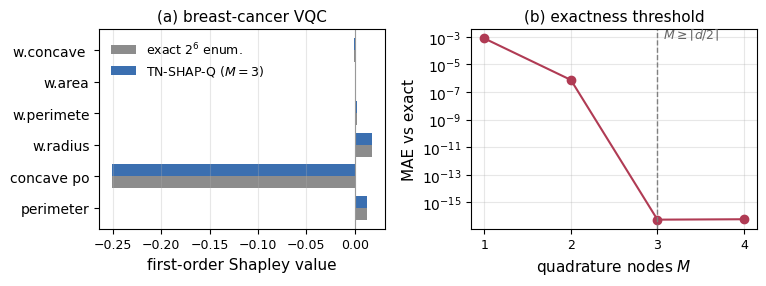

saved figures/fig_benchmark.png


In [5]:
# Figure: (a) feature Shapley exact vs Owen (hero); (b) exactness threshold at M=ceil(d/2)=3
hero = 0
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.8, 3.0))
xb = np.arange(D); wid = 0.38
a1.barh(xb - wid/2, phi_exact[hero], wid, color='0.55', label=r'exact $2^6$ enum.')
a1.barh(xb + wid/2, phi_M3[hero], wid, color='#3b6fb0', label=r'TN-SHAP-Q ($M{=}3$)')
a1.axvline(0, color='0.6', lw=0.8); a1.set_yticks(xb); a1.set_yticklabels(short)
a1.set_xlabel('first-order Shapley value'); a1.set_title('(a) breast-cancer VQC')
a1.legend(frameon=False); a1.grid(alpha=0.3, axis='x')

a2.semilogy(Ms, np.clip(mae_by_M, 1e-18, None), 'o-', color='#b03b54')
a2.axvline(M_EXACT, color='0.5', ls='--', lw=1)
a2.text(M_EXACT + 0.06, mae_by_M[0], r'$M\geq\lceil d/2\rceil$', color='0.4', fontsize=9)
a2.set_xticks(Ms); a2.set_xlabel('quadrature nodes $M$'); a2.set_ylabel('MAE vs exact')
a2.set_title('(b) exactness threshold'); a2.grid(alpha=0.3, which='both')
fig.tight_layout()
savefig(fig, 'fig_benchmark.png')
plt.show()
print("saved figures/fig_benchmark.png")

In [6]:
res = {
    "task": "breast-cancer single-RY VQC feature Shapley",
    "dataset": "breast_cancer", "d": D, "train_acc": acc,
    "feature_names": names, "feature_idx": [int(i) for i in feat_idx],
    "M": int(M_EXACT), "threshold_M": int(M_EXACT), "evals": int(evals), "enum_evals": int(2**D),
    "mae": mae3, "cosine": cos3, "mae_M2": mae2,
    "mae_by_M": {str(M): float(v) for M, v in zip(Ms, mae_by_M)},
    "threshold_ok": bool(mae3 < 1e-10 and mae2 > 1e-7),
}
save_results("08", res)
print("saved results/08.json")

saved results/08.json


In [7]:
# Verification: exact recovery on a real benchmark; threshold confirmed
np.testing.assert_allclose(phi_M3, phi_exact, atol=1e-10, rtol=0)
assert mae2 > 1e-7, "M=2 must be inexact below the threshold for d=6"
print(f"PASS  breast-cancer VQC (acc {acc:.3f}): Owen M={M_EXACT} reproduces 2^{D} enumeration "
      f"(MAE={mae3:.2e}, cosine={cos3:.6f}, {evals} evals vs {2**D}); M=2 inexact (MAE={mae2:.2e}).")

PASS  breast-cancer VQC (acc 0.917): Owen M=3 reproduces 2^6 enumeration (MAE=5.66e-17, cosine=1.000000, 36 evals vs 64); M=2 inexact (MAE=7.50e-07).
